<a href="https://colab.research.google.com/github/nimitha123-kd/Take-IT-Smart-Internship/blob/main/TIS_INDEPENDENT_PROJ_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

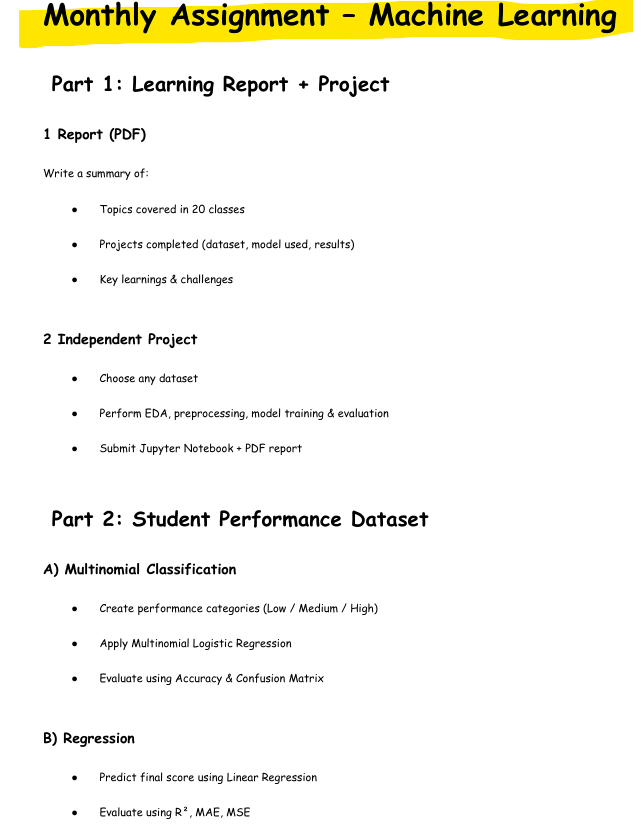

#  *****2)   INDEPENDENT DATASET*****
# **Author : K D Nimitha(2NR22AD012)**

# **1. Problem Statement**


# Example: Analyze AI job market trends to understand demand, salaries, and skills

# 2. **OBJECTIVES**
   - To explore, clean, and visualize the AI Job Market dataset in order to understand its structure, detect patterns, and prepare it for machine learning modeling.

# **3. LOAD LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **4. LOAD DATASET**

In [ ]:
# 4. Load Data
df = pd.read_csv("AI Job Market Dataset.csv")
print(df)


       job_id                  job_title company_size company_industry  \
0           1                AI Engineer      Startup           Retail   
1           2  Machine Learning Engineer          MNC       Technology   
2           3  Machine Learning Engineer          MNC       Technology   
3           4           Business Analyst      Startup       Healthcare   
4           5             Data Scientist          MNC       Healthcare   
...       ...                        ...          ...              ...   
10340   10341              Data Engineer      Startup       Technology   
10341   10342               Data Analyst       Medium       Healthcare   
10342   10343  Machine Learning Engineer      Startup        Education   
10343   10344              Data Engineer          MNC       E-commerce   
10344   10345                AI Engineer      Startup        Education   

         country remote_type experience_level  years_experience  \
0         Canada      Remote           Senio

# **5. Understand the Data / Domain Analysis**

In [ ]:
# 5. Understand the Data / Domain Analysis
print(df.head())
print()
print(df.tail())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.dtypes)
print()


   job_id                  job_title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud  \
0              0         

# **6. Basic Checks**


In [ ]:
#6. Basic Checks
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Shape: (10345, 19)
Missing values:
 job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64
Duplicates: 0


# **7. Data Cleaning**
- handle missing values
- handle duplicates

In [ ]:
# Handle missing values
df.ffill(inplace=True)   # Using ffill directly
# ffill (forward fill) is a method in pandas used to fill NaN (missing) values in a DataFrame.
# It propagates the last valid observation forward to next valid observation. In simpler terms, it fills missing values with the value from the previous row
# # Handle duplicates
df.drop_duplicates(inplace=True)


# **8. Data wrangling**
* merge
* drop columns
* rename columns
* create new columns

In [ ]:
# 8. Data Wrangling
#  renaming columns
df.rename(columns={'job_title':'Job_Title','salary':'Salary'}, inplace=True)
# Creating new column
df['Salary_in_lakhs'] = df['Salary'] / 100000
print(df.head())
print(df.shape)

   job_id                  Job_Title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud  \
0              0         

# **9. Data Visualization**
- Univariate
- Bivariate
- Multi variate

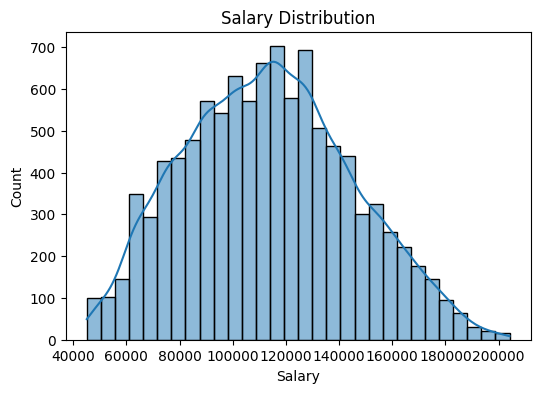

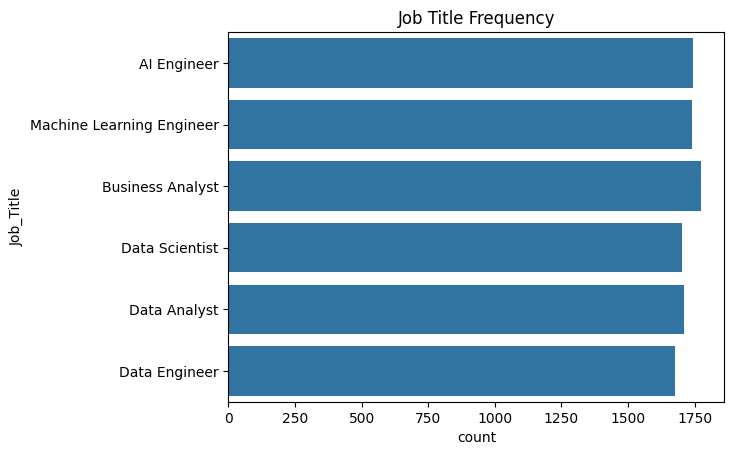

In [ ]:

# Univariate
plt.figure(figsize=(6,4))
sns.histplot(df['Salary'], bins=30, kde=True)
plt.title("Salary Distribution")
plt.show()

sns.countplot(y='Job_Title', data=df)
plt.title("Job Title Frequency")
plt.show()





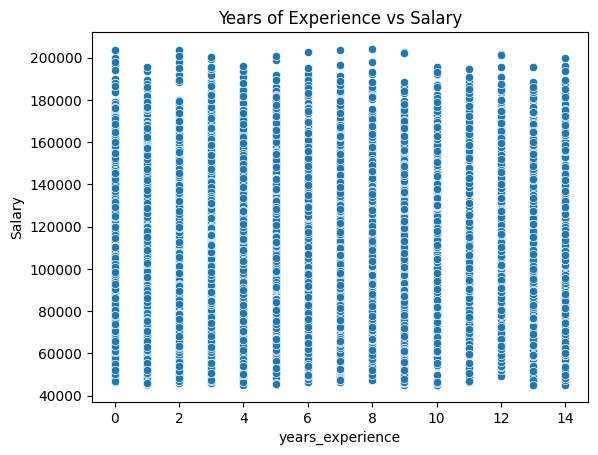

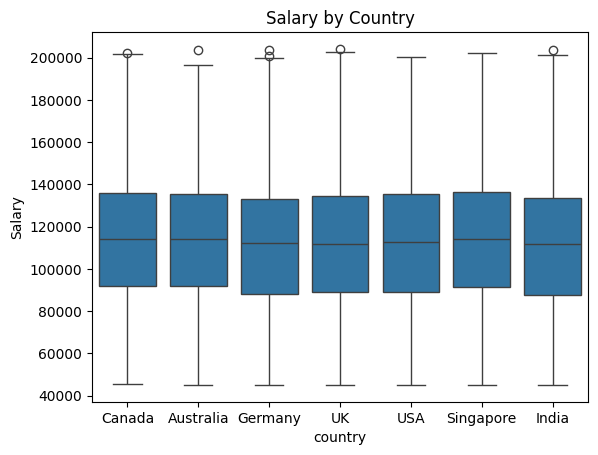

In [ ]:
# Bivariate
sns.scatterplot(x='years_experience', y='Salary', data=df)
plt.title('Years of Experience vs Salary')
plt.show()

sns.boxplot(x='country', y='Salary', data=df)
plt.title('Salary by Country')
plt.show()

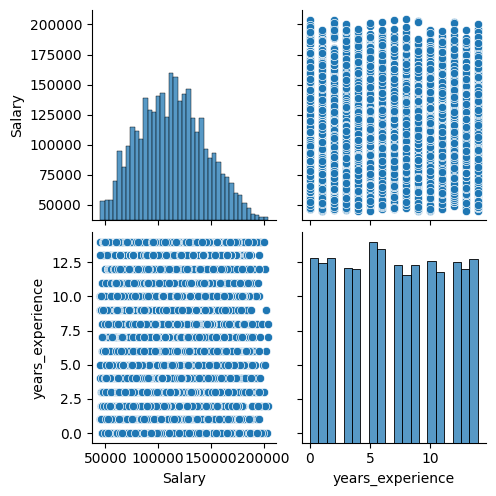

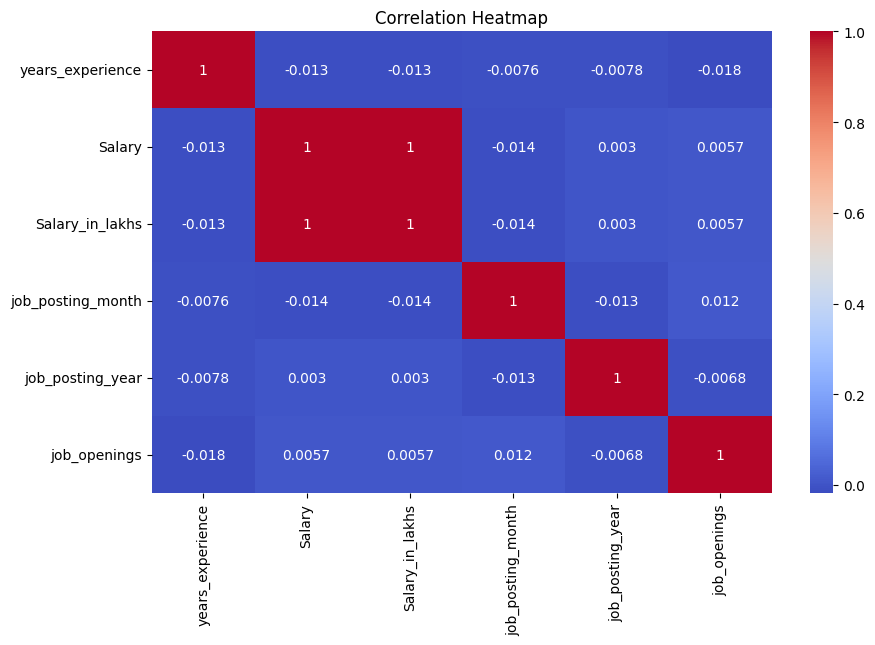

In [ ]:
# Multivariate
sns.pairplot(df[['Salary','years_experience']])
plt.show()

plt.figure(figsize=(10,6))
# Select only numerical columns for correlation heatmap, excluding job_id
numerical_cols = ['years_experience', 'Salary', 'Salary_in_lakhs', 'job_posting_month', 'job_posting_year', 'job_openings']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Insights**

**Salary Distribution (Histogram/KDE)**:  
The majority of salaries fall within a mid-range, with a few high-paying outliers indicating specialized or senior roles.



**Job Title Frequency (Countplot):**  
Certain job titles dominate the dataset, suggesting strong demand for roles like Data Scientist or ML Engineer.



**Experience vs Salary (Scatterplot)**
There is a positive correlation between years of experience and salary, though some exceptions show high salaries even at lower experience levels.



**Salary by Location (Boxplot):**  
Salaries vary significantly across locations, with metropolitan areas offering higher median pay compared to smaller cities.



**Pairplot (Multivariate):**
Salary tends to increase with both experience and skills_count, showing that multiple factors jointly influence compensation.



**Correlation Heatmap:**  
Salary is strongly correlated with experience and skills_count, while weaker correlations exist with other variables.

# **Preprocessing**



In [ ]:
# Preprocessing
# Select features and target
X = df[['years_experience','country']]   # categorical features
y = df['Salary']                        # target variable

# Handle missing values (simple fill) - (already handled by ffill earlier, but kept for robustness)
X = X.ffill() # Updated to use ffill() directly
y = y.fillna(y.mean())

# Apply one-hot encoding to categorical features in X
X = pd.get_dummies(X, columns=['years_experience', 'country'], drop_first=True)
print(X.head())

   years_experience_1  years_experience_2  years_experience_3  \
0               False                True               False   
1               False               False               False   
2               False               False               False   
3               False               False               False   
4               False               False               False   

   years_experience_4  years_experience_5  years_experience_6  \
0               False               False               False   
1               False               False               False   
2               False               False               False   
3               False               False               False   
4               False                True               False   

   years_experience_7  years_experience_8  years_experience_9  \
0               False               False               False   
1               False               False               False   
2               False  

# **Train / Test Split**

In [ ]:
# Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# **Model Training**

In [ ]:
# Model Training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Prediction**

In [ ]:
# Prediction
y_pred = model.predict(X_test)

# **Evaluation**

In [ ]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.004871319188934464
RMSE: 31631.406363015405


# **10. Conclusion**

 The exploratory data analysis highlighted key drivers of AI job market salaries — experience, skills, and location. After cleaning and wrangling, the dataset was used to train a simple linear regression model, which provided baseline predictive performance. While the model captures general trends, further improvements with advanced algorithms and richer feature engineering could yield more accurate insights for HR and job market analysis.